In [4]:
import pickle
import re
import ipywidgets as widgets
from IPython.display import display

# Load schedules

In [8]:
from src import project_dir

examined_directory = f'{project_dir}/logs/partition___2024.05.03-18.09.05.436'
examined_directory = f'{project_dir}/latest_log_dir'

with open(f'{examined_directory}/baseline.results.pkl', 'rb') as f1, open(f'{examined_directory}/partition.results.pkl', 'rb') as f2:
    ours = pickle.load(f1)
    partition = pickle.load(f2)

ours.keys(), partition.keys()

(dict_keys(['energy', 'latency', 'area', 'schedule', 'state', 'constraints', 'latest_energy', 'latest_latency', 'latest_area']),
 dict_keys(['best_partition', 'best_schedule', 'best_energy', 'best_latency', 'best_edp']))

In [9]:
schedule_ours = ours['schedule']
schedule_partition = partition['best_schedule']
energy_dict_ours = ours['energy']
latency_dict_ours = ours['latency']
partition_items = partition['best_partition']

# Analytical logging of consecutive entries & idle times

In [34]:
schedule_ours.bins

[EyerissAcceleratorState(pe_array_x=16, pe_array_y=10, precision=5, sram_size=108000, ifmap_spad_size=32, weights_spad_size=512, psum_spad_size=80),
 EyerissAcceleratorState(pe_array_x=25, pe_array_y=12, precision=6, sram_size=108000, ifmap_spad_size=64, weights_spad_size=256, psum_spad_size=32),
 EyerissAcceleratorState(pe_array_x=16, pe_array_y=25, precision=7, sram_size=108000, ifmap_spad_size=24, weights_spad_size=320, psum_spad_size=32),
 EyerissAcceleratorState(pe_array_x=25, pe_array_y=8, precision=8, sram_size=108000, ifmap_spad_size=64, weights_spad_size=384, psum_spad_size=48)]

In [12]:
for accel, entries in schedule_ours.as_dict(main_key='bin').items():
    print(f'B{accel.precision}')
    print('\t' + '\n\t'.join(f'{entry.tag}: {entry.start:.3e}->{entry.end:.3e}' for entry in entries))
    print("Idle times:")
    idle_times = [(entries[i].end, entries[i+1].start) for i in range(len(entries)-1)
                  if entries[i].end != entries[i+1].start]
    print('\t' + '\n\t'.join(f'{times[0]:.3e}->{times[1]:.3e}' for times in idle_times))

B7
	resnet50: 0.000e+00->5.481e+08
	mobilenetv2: 5.481e+08->1.142e+09
Idle times:
	
B8
	efficientnet: 0.000e+00->4.881e+08
Idle times:
	
B6
	vgg11: 0.000e+00->1.019e+08
	resnet18: 1.019e+08->4.742e+08
	vgg16: 4.742e+08->6.831e+08
Idle times:
	


In [36]:
schedule_partition.bins

[1, 2, 3, 4]

In [13]:
for bin, entries in schedule_partition.as_dict(main_key='bin').items():
    print(f'Bin{bin}')
    consecutive = all(entries[i].start <= entries[i+1].end for i in range(len(entries) - 1))
    print(f'\tAre all entries consecutive? {consecutive}')
    # entry duration
    print('\t\t' + '\n\t\t'.join(f'{entry.tag}: {entry.start:.3e}->{entry.end:.3e}' for entry in entries))

    idle_times = [(entries[i].tag, entries[i].end, entries[i+1].tag, entries[i+1].start) for i in range(len(entries)-1)
                  if entries[i].end != entries[i+1].start]
    total_time = entries[-1].end
    total_idle_time = sum(start-end for _, end, _, start in idle_times)

    print(f"\tIdle times: {100 * total_idle_time/total_time:.2f}% ({total_idle_time:.3e}/{total_time:.3e})")
    # individual idle times
    print('\t\t' + '\n\t\t'.join(f'({times[0]}) {times[1]:.3e} -> {times[3]:.3e} ({times[2]})' for times in idle_times))    

Bin1
	Are all entries consecutive? True
		mobilenetv2_133_3: 0.000e+00->9.175e+00
		resnet50_104_3: 9.175e+00->9.175e+00
		resnet50_104_4: 9.175e+00->3.224e+01
		mobilenetv2_133_7: 3.224e+01->3.224e+01
		resnet50_104_7: 9.935e+01->2.755e+02
		mobilenetv2_133_11: 2.755e+02->2.755e+02
		resnet18_72_1: 2.755e+02->2.834e+02
		resnet50_104_11: 2.834e+02->2.834e+02
		resnet50_104_12: 2.834e+02->3.767e+02
		resnet50_104_15: 4.449e+02->5.329e+02
		resnet50_104_17: 5.329e+02->6.168e+02
		resnet50_104_19: 6.168e+02->6.168e+02
		resnet18_72_3: 6.168e+02->6.168e+02
		efficientnet_317_3: 6.168e+02->6.168e+02
		vgg11_32_3: 6.168e+02->6.168e+02
		vgg11_32_4: 6.168e+02->6.168e+02
		mobilenetv2_133_20: 1.098e+03->1.101e+03
		resnet50_104_23: 1.178e+03->1.178e+03
		resnet18_72_7: 1.351e+03->1.351e+03
		mobilenetv2_133_28: 1.471e+03->1.857e+03
		mobilenetv2_133_31: 1.857e+03->1.857e+03
		mobilenetv2_133_35: 1.863e+03->1.872e+03
		mobilenetv2_133_36: 1.872e+03->2.249e+03
		mobilenetv2_133_39: 2.252e+03->2

In [23]:
nns = list({re.search('(.*)_\d+$', entry.tag).group(1) for entry in schedule_partition.entries})
entries_per_nn = {nn: [entry for entry in schedule_partition.entries if nn in entry.tag] for nn in nns}
for nn, entries in entries_per_nn.items():
    print(nn)
    consecutive = all(entries[i].end <= entries[i+1].start for i in range(len(entries) - 1))
    exec_time = sum(entry.end - entry.start for entry in entries)
    idle_time = sum(entries[i+1].start - entries[i].end for i in range(len(entries)-1)
                    if entries[i].end != entries[i+1].start)
    
    print(f'\tAre all entries consecutive? {consecutive}')
    print(f'\tExecution time: {exec_time}')
    print(f'\tIdle time: {idle_time}')
    print(f'\tRatio idle/execution: {idle_time/exec_time:.3e}')
    # print('\t' + '\n\t'.join(f'{entry.tag}: {entry.start:,}->{entry.end:,}' for entry in entries))

resnet18_72
	Are all entries consecutive? True
	Execution time: 2623.8402680000004
	Idle time: 2866.5446779999997
	Ratio idle/execution: 1.092e+00
efficientnet_317
	Are all entries consecutive? True
	Execution time: 1173.3317259999994
	Idle time: 6967.301804000001
	Ratio idle/execution: 5.938e+00
vgg16_20
	Are all entries consecutive? True
	Execution time: 1262.1906019999992
	Idle time: 4574.388266
	Ratio idle/execution: 3.624e+00
mobilenetv2_133
	Are all entries consecutive? True
	Execution time: 4271.964202
	Idle time: 776.667142
	Ratio idle/execution: 1.818e-01
resnet50_104
	Are all entries consecutive? True
	Execution time: 3318.1204860000007
	Idle time: 3671.2366199999997
	Ratio idle/execution: 1.106e+00
vgg11_32
	Are all entries consecutive? True
	Execution time: 349.0611260000002
	Idle time: 1925.3494059999998
	Ratio idle/execution: 5.516e+00


# Evaluation metrics

In [18]:
ours_d = schedule_ours.as_dict(main_key='bin')
part_d = schedule_partition.as_dict(main_key='bin')

ours_energy = sum([
    energy_dict_ours[(entry.tag, entry.bin)]
    for entry in schedule_ours.entries
])
ours_latency = max([
    sum([
        latency_dict_ours[(entry.tag, entry.bin)] for entry in entries
    ]) for bin, entries in ours_d.items()
])

part_energy = sum([
    instance.metrics.overall_energy + instance.metrics.overall_link_energy
    for instance in partition_items.values()
]) * 1e3
part_latency = max([
    entries[-1].end
    for bin, entries in part_d.items()
]) * 1e6
print(f'Ours: Energy ({ours_energy:.3e}) * Max Latency ({ours_latency:.3e}) = EDP ({ours_energy * ours_latency:.3e})')
print(f'Partition: Energy ({part_energy:.3e}) * Max Latency ({part_latency:.3e}) = EDP ({part_energy * part_latency:.3e})')

Ours: Energy (3.554e+06) * Max Latency (1.142e+09) = EDP (4.059e+15)
Partition: Energy (2.145e+06) * Max Latency (8.150e+09) = EDP (1.748e+16)


In [24]:
exec_times_ours_str = {f'{accel.precision}b': f'{v:.3e}' for accel, v in schedule_ours.end_timestamp.items()}
assert {bin: entries[-1].end for bin, entries in part_d.items()} == schedule_partition.end_timestamp
exec_times_partition_str = {bin: f'{v*1e6:.3e}' for bin, v in schedule_partition.end_timestamp.items()}
print(f"Total execution times per bin:\n\tOurs: {exec_times_ours_str}\n\tPartition: {exec_times_partition_str}")

Total execution times per bin:
	Ours: {'5b': '0.000e+00', '6b': '6.831e+08', '7b': '1.142e+09', '8b': '4.881e+08'}
	Partition: {1: '7.258e+09', 2: '8.150e+09', 3: '7.785e+09', 4: '7.334e+09'}


In [33]:
idle_time_ours = {f'{accel.precision}b': ours_latency - schedule_ours.end_timestamp[accel] for accel in ours_d.keys()}
idle_time_ours_str = {k: f'{v:.3e}' for k, v in idle_time_ours.items()}
idle_exec_time_part = {bin: sum(entries[i+1].start - entries[i].end for i in range(len(entries)-1))
                       for bin, entries in part_d.items()}
idle_time_part = {bin: exec_idle_time + (part_latency - schedule_partition.end_timestamp[bin])
                  for bin, exec_idle_time in idle_exec_time_part.items()}
idle_time_part_str = {k: f'{v:.3e}' for k, v in idle_time_part.items()}
print(f"Total idle time per bin, compared to the maximum execution time:\n\tOurs: {idle_time_ours_str}\n\tPartition: {idle_time_part_str}")

Total idle time per bin, compared to the maximum execution time:
	Ours: {'7b': '0.000e+00', '8b': '6.542e+08', '6b': '4.592e+08'}
	Partition: {1: '8.150e+09', 2: '8.150e+09', 3: '8.150e+09', 4: '8.150e+09'}


# Plots for schedules

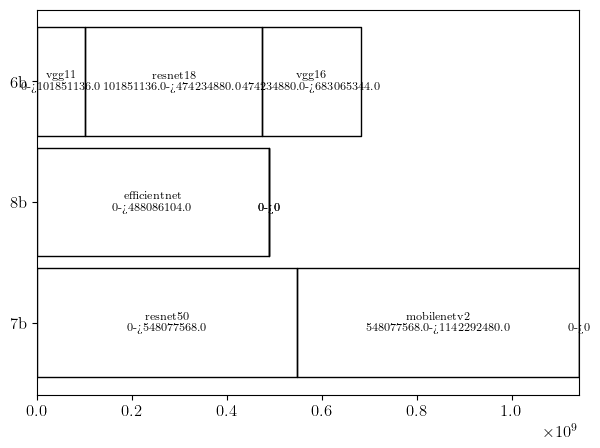

In [37]:
# %matplotlib inline
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
from matplotlib import pyplot as plt
from matplotlib import rcParams
from collections import namedtuple
import numpy as np

ScheduleEntry = namedtuple('ScheduleEntry',
                           ['start', 'end', 'bin', 'tag'])

schedule = schedule_ours
rcParams.update({
        # 'text.latex.preamble': r"\usepackage{lmodern}",
        'font.size': "12",    
        "text.usetex": True,
        "font.family": "lmodern",
        "font.serif": ["Computer Modern Roman"]
    })

figsize = (7, 5)

# organize schedule in batches: each batch contains one item per bin, and
# there are as many batches as max number of items in one bin
bin_dict = schedule.as_dict('bin')
batch_entries = []
batch_index = 0
last_added = True
while last_added:
    this_batch = []
    last_added = False
    for bin, bin_entries in bin_dict.items():
        try:
            entry_for_this_batch = bin_entries[batch_index]
            this_batch.append(entry_for_this_batch)
            last_added = True
        except IndexError:
            this_batch.append(ScheduleEntry(0, 0, bin, tag=''))

    if last_added:
        batch_entries.append(this_batch)
        batch_index += 1

# build schedule figure
fig, ax = plt.subplots(figsize=figsize)
left = np.zeros(len(bin_dict))
for batch_entry in batch_entries:
    widths = [entry.end - entry.start for entry in batch_entry]
    y = [f'{bin.precision}b' for bin in bin_dict.keys()]

    bar_container = ax.barh(y=y,
                            width=widths,
                            height=0.9,
                            align='center',
                            left=left,
                            joinstyle='round',
                            capstyle='round',
                            fill=False,
                            linewidth=1.0,
                            edgecolor='black',)
    # ax.semilogx()
    ax.bar_label(bar_container,
                 labels=[f'{entry.tag}\n{entry.start}->{entry.end}'
                          for entry in batch_entry],
                 label_type='center',
                 fontsize='x-small',
                 color='black')
    left += widths

plt.show()

Idle times are NOT taken into account


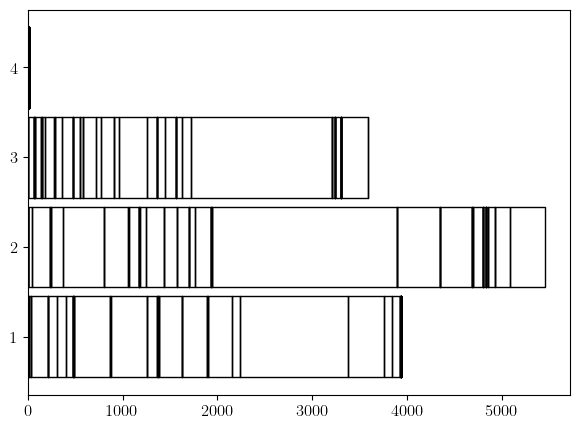

In [38]:
# %matplotlib inline
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
from matplotlib import pyplot as plt
from matplotlib import rcParams
from collections import namedtuple
import numpy as np

ScheduleEntry = namedtuple('ScheduleEntry',
                           ['start', 'end', 'bin', 'tag'])

schedule = schedule_partition
rcParams.update({
        # 'text.latex.preamble': r"\usepackage{lmodern}",
        'font.size': "12",    
        "text.usetex": True,
        "font.family": "lmodern",
        "font.serif": ["Computer Modern Roman"]
    })

figsize = (7, 5)

# organize schedule in batches: each batch contains one item per bin, and
# there are as many batches as max number of items in one bin
bin_dict = schedule.as_dict('bin')
batch_entries = []
batch_index = 0
last_added = True
while last_added:
    this_batch = []
    last_added = False
    for bin, bin_entries in bin_dict.items():
        try:
            entry_for_this_batch = bin_entries[batch_index]
            this_batch.append(entry_for_this_batch)
            last_added = True
        except IndexError:
            this_batch.append(ScheduleEntry(0, 0, bin, tag=''))

    if last_added:
        batch_entries.append(this_batch)
        batch_index += 1

# build schedule figure
fig, ax = plt.subplots(figsize=figsize)
left = np.zeros(len(bin_dict))
for batch_entry in batch_entries:
    widths = [entry.end - entry.start for entry in batch_entry]
    y = [f'{bin}' for bin in bin_dict.keys()]

    bar_container = ax.barh(y=y,
                            width=widths,
                            height=0.9,
                            align='center',
                            left=left,
                            joinstyle='round',
                            capstyle='round',
                            fill=False,
                            linewidth=1.0,
                            edgecolor='black',)
    # ax.semilogx()
    # ax.bar_label(bar_container,
    #              labels=[f'{entry.tag}\n{entry.start}->{entry.end}'
    #                       for entry in batch_entry],
    #              label_type='center',
    #              fontsize='x-small',
    #              color='black')
    left += widths


print('\033[91m' + 'Idle times are NOT taken into account' + '\033[0m')
plt.show()